In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.special import erf



# Packages
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Atmosphere parameters
Cn2_h0 = 1e-17                          # baseline Cn^2 [m^(-2/3)] (weak: 1e-17, strong: 1e-12)
V = 23                                  # visibility [km]
vG = 5.0                                # ground wind [m/s] (weak: 5, strong: 10)
vT = 20.0                               # tropopause wind [m/s] (weak: 20, strong: 30)
HT = 12000.0                            # tropopause height [m]
LT = 1000.0                             # tropopause thickness [m]
M = 1                                   # turbulence scaling
RE = 6370e3                             # Earth radius [m]
L0 = 50                                 # turbulence outer scale (100-50) [m] (size of largest eddies)
phi = np.deg2rad(90)                    # angle between the wind direction and the zenith

# Satellite parameters
H_sat = 300e3                           # satellite altitude [m]
zeta = np.deg2rad(30)                   # zenith angle

# Receiver parameters 
hg = 100                                # ground elevation above sea level [m]
h0 = 10                                 # ground station elevation [m]    
f_receiver = 1.0                        # Focal length [m]
D = 0.7                                 # receiver aperture diameter [m]

lam = 1550e-9                           # wavelength [m]
k = 2*np.pi/lam                         # wavenumber [1/m]


# Link geometry
L_path = np.sqrt((RE + H_sat)**2 +
                 (RE + h0)**2 * (np.cos(zeta)**2 - 1)) \
        - (RE + h0) * np.cos(zeta)

In [6]:
# Kim model 
def p_func(V):
    """Gives the exponent p in the Kim model based on visibility V [km]"""
    if V > 50: return 1.6
    elif 6 <= V <= 50: return 1.3
    elif 1 <= V < 6: return 0.16 * V + 0.34
    elif 0.5 <= V < 1: return V - 0.5
    elif V < 0.5: return 0
    else: return 1.3

# Wind velocity profile
def v_profile(hh, zeta):
    bracket = np.sqrt(np.sin(phi)**2 + (np.cos(phi)**2) * (np.cos(zeta)**2))
    return vG + vT * np.exp(-(((hh + hg) * np.cos(zeta) - HT) / LT)**2) * bracket

# Refractive index structure parameter model (Stotts et al. 2023)
def Cn2_profile(hh, h0):
    vhh = v_profile(hh, zeta)
    term1 = 1.04e-3 * (9.0 / vhh)**2 * ((hh + hg)/1e5)**10 * np.exp(-(hh+hg)/1200.0)
    term2 = 2.7e-16 * np.exp(-(hh+hg)/1700.0)
    term3 = Cn2_h0 * (h0 / (hh + 1e-9))**(4/3)
    return M * (term1 + term2) + term3


def calculate_physics_params(w0_initial):

    integral_Cn2, _ = quad(lambda hh: Cn2_profile(hh, h0), h0, HT)
    # Fried param
    r0 = (0.423*k**2*(1/np.cos(zeta))*integral_Cn2)**(-3/5)

    # Coherence time
    num, _ = quad(lambda hh: Cn2_profile(hh, h0)* (v_profile(hh, zeta)**(5/3)), h0, HT)
    v0 = (num/integral_Cn2)**(3/5)
    tau0 = 0.314 * np.cos(zeta) * r0 / v0

    # Tilt variance
    beta2 = 2.91*(1/np.cos(zeta))*integral_Cn2*D**(-1/3)

    # RMS focal displacement
    r_rms = f_receiver*np.sqrt(beta2)


    # Turbulence + diffraction focal spot
    w_focal = np.sqrt(
        (1.22*lam*f_receiver/D)**2 +
        (0.98*lam*f_receiver/r0)**2
    )

    # Diffraction beam radius at receiver
    w_L = w0_initial*np.sqrt(
        1 + (lam*L_path/(np.pi*w0_initial**2))**2
    )

    return r_rms, w_focal, tau0, w_L

In [7]:
# Jitter computation
w0_input = 0.1

jitter_rms, w_focal, tau0_calc, w_aperture = \
    calculate_physics_params(w0_input)


# Turbulence jitter simulation
fs = 10000
dt = 1/fs
steps = 10000
gain = 0.5              #FSM response gain

np.random.seed(42)

alpha = dt/tau0_calc

white_x = np.random.normal(0, jitter_rms, steps)
white_y = np.random.normal(0, jitter_rms, steps)

beam_x = np.zeros(steps)
beam_y = np.zeros(steps)

# Ornstein–Uhlenbeck turbulence models
for i in range(1,steps):

    beam_x[i] = beam_x[i-1]*(1-alpha) + white_x[i]*alpha
    beam_y[i] = beam_y[i-1]*(1-alpha) + white_y[i]*alpha


beam_x *= jitter_rms/np.std(beam_x)
beam_y *= jitter_rms/np.std(beam_y)



# FSM control loop
fsm_x = 0
fsm_y = 0

hist_open_x = []
hist_closed_x = []


def qd_response(x,y,sigma):

    rx = 0.5*(1+erf(x/(sigma*np.sqrt(2))))
    ty = 0.5*(1+erf(y/(sigma*np.sqrt(2))))

    A = rx*ty
    B = rx*(1-ty)
    C = (1-rx)*ty
    D = (1-rx)*(1-ty)

    total = A+B+C+D

    if total <= 0:
        return 0,0

    err_x = ((A+B)-(C+D))/total
    err_y = ((A+C)-(B+D))/total

    return err_x,err_y


for t in range(steps):

    hist_open_x.append(beam_x[t]*1e6)

    resid_x = beam_x[t]-fsm_x
    resid_y = beam_y[t]-fsm_y

    err_x,err_y = qd_response(resid_x,resid_y,w_focal)

    fsm_x += err_x*w_focal*gain
    fsm_y += err_y*w_focal*gain

    hist_closed_x.append(resid_x*1e6)


# Statistics
settling = int(0.1*fs)

std_open = np.std(hist_open_x[settling:])
std_closed = np.std(hist_closed_x[settling:])

reduction = (std_open-std_closed)/std_open

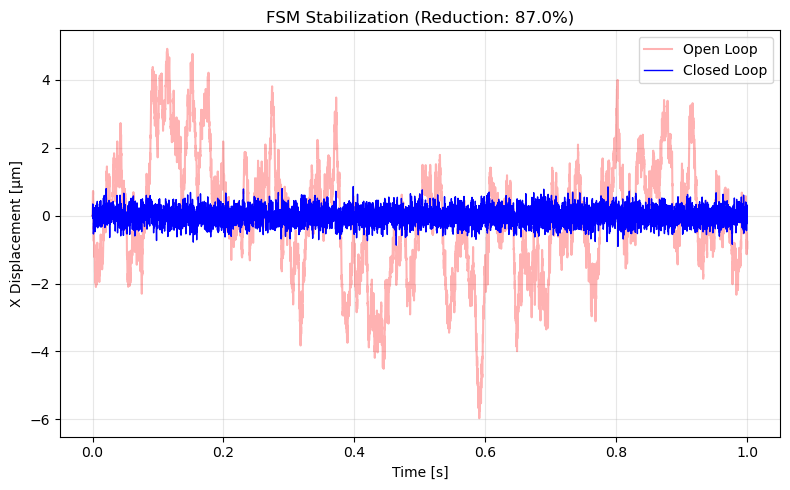

In [8]:
# Plot
plt.figure(figsize=(8,5))

plt.plot(np.linspace(0,1,len(hist_open_x)),
         hist_open_x,
         'r',
         alpha=0.3,
         label='Open Loop')

plt.plot(np.linspace(0,1,len(hist_closed_x)),
         hist_closed_x,
         'b',
         lw=1,
         label='Closed Loop')

plt.xlabel("Time [s]")
plt.ylabel("X Displacement [µm]")
plt.title(f"FSM Stabilization (Reduction: {reduction*100:.1f}%)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()